**Google Colab Lab Assignment -NLP**
Course Name: Deep Learning

Lab Title: NLP Techniques for Text Classification

Group Member  Name:
1) Nirmal Chaturvedi
202201040210
2) Vivek Borade
202201040214
3) Abhijeet Jadhav
202201040122



Date of Submission: 13-4-25

Objective The objective of this assignment is to implement NLP preprocessing techniques and build a text classification model using machine learning techniques.

Learning Outcomes:

Understand and apply NLP preprocessing techniques such as tokenization, stopword removal, stemming, and lemmatization.

Implement text vectorization techniques such as TF-IDF and CountVectorizer.

Develop a text classification model using a machine learning algorithm.

Evaluate the performance of the model using suitable metrics.

Part 1: NLP Preprocessing

Dataset Selection:

Choose any text dataset from Best Datasets for Text https://en.innovatiana.com/post/best-datasets-for-text-classification Classification, such as SMS Spam Collection, IMDb Reviews, or any other relevant dataset.

Download the dataset and upload it to Google Colab.

Load the dataset into a Pandas DataFrame and explore its structure (e.g., check missing values, data types, and label distribution).

Text Preprocessing:

Convert text to lowercase.

Perform tokenization using NLTK or spaCy.

Remove stopwords using NLTK or spaCy.

Apply stemming using PorterStemmer or SnowballStemmer.

Apply lemmatization using WordNetLemmatizer.

Vectorization Techniques:

Convert text data into numerical format using TF-IDF and CountVectorizer

In [17]:
import os
import pandas as pd
import nltk
import zipfile
import requests
import io
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# -----------------------------
# Step 0: Setup NLTK Downloads
# -----------------------------
# Make sure the required NLTK data is available
nltk_data_path = os.path.join(os.getcwd(), "nltk_data")
if not os.path.exists(nltk_data_path):
    os.makedirs(nltk_data_path)

# Download necessary NLTK data
print("Downloading NLTK resources...")
nltk.download('punkt', download_dir=nltk_data_path)
nltk.download('stopwords', download_dir=nltk_data_path)
nltk.download('wordnet', download_dir=nltk_data_path)
nltk.download('omw-1.4', download_dir=nltk_data_path)
nltk.download('averaged_perceptron_tagger', download_dir=nltk_data_path)
nltk.download('maxent_ne_chunker', download_dir=nltk_data_path)
nltk.download('words', download_dir=nltk_data_path)
nltk.download('punkt_tab', download_dir=nltk_data_path)
nltk.download('averaged_perceptron_tagger_eng', download_dir=nltk_data_path)
nltk.download('maxent_ne_chunker_tab', download_dir=nltk_data_path)

# Add NLTK data path to the NLTK library
nltk.data.path.append(nltk_data_path)

print("NLTK resources are up-to-date!")

# -----------------------------
# Step 1: Download & Extract Dataset
# -----------------------------
zip_url = "http://thinknook.com/wp-content/uploads/2012/09/Sentiment-Analysis-Dataset.zip"
response = requests.get(zip_url)

# Extract the dataset
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    zip_ref.extractall("sentiment_data")

# Read dataset into a DataFrame
df = pd.read_csv(
    "sentiment_data/Sentiment Analysis Dataset.csv",
    encoding='ISO-8859-1',
    quotechar='"',
    on_bad_lines='skip'
)

# Rename columns
df.columns = ["ItemID", "Sentiment", "SentimentSource", "SentimentText"]

# -----------------------------
# Step 2: Dataset Overview
# -----------------------------
print("\n--- Dataset Preview ---")
print(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Label Distribution ---")
print(df['Sentiment'].value_counts())

# -----------------------------
# Step 3: Text Preprocessing
# -----------------------------
# Initialize NLTK utilities
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Define the text preprocessing function
def preprocess_text(text):
    text = str(text).lower()  # Convert to lowercase
    tokens = word_tokenize(text)  # Tokenize the text
    tokens = [word for word in tokens if word.isalpha()]  # Remove punctuation/numbers
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Apply lemmatization
    return ' '.join(tokens)  # Join tokens back into a string

# Apply preprocessing function to the SentimentText column
df['cleaned_text'] = df['SentimentText'].apply(preprocess_text)

# Display a sample of cleaned text
print("\n--- Cleaned Text Sample ---")
print(df[['SentimentText', 'cleaned_text']].head())

# -----------------------------
# Step 4: Vectorization
# -----------------------------
# CountVectorizer (Bag of Words)
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(df['cleaned_text'])

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])

# Display vectorization completion and shapes
print("\n--- Vectorization Complete ---")
print(f"CountVectorizer shape: {X_count.shape}")
print(f"TF-IDF shape: {X_tfidf.shape}")


NLTK resources are up-to-date!


[nltk_data] Downloading package punkt to /content/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /content/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /content/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /content/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /content/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /content/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /content/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to /content/nltk_data...
[n


--- Dataset Preview ---
   ItemID  Sentiment SentimentSource  \
0       1          0    Sentiment140   
1       2          0    Sentiment140   
2       3          1    Sentiment140   
3       4          0    Sentiment140   
4       5          0    Sentiment140   

                                       SentimentText  
0                       is so sad for my APL frie...  
1                     I missed the New Moon trail...  
2                            omg its already 7:30 :O  
3            .. Omgaga. Im sooo  im gunna CRy. I'...  
4           i think mi bf is cheating on me!!!   ...  

--- Missing Values ---
ItemID             0
Sentiment          0
SentimentSource    0
SentimentText      0
dtype: int64

--- Label Distribution ---
Sentiment
1    790177
0    788435
Name: count, dtype: int64

--- Cleaned Text Sample ---
                                       SentimentText  \
0                       is so sad for my APL frie...   
1                     I missed the New Moon trail...  

In [9]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split



# Step 2: Text Vectorization
df['cleaned'] = df['SentimentText'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# Step 3: Vectorization

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned'])

# Count Vectorizer
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(df['cleaned'])

# Target variable (Sentiment): 1 = Positive, 0 = Negative
y = df['Sentiment']

# Train-test split (80% train, 20% test)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
X_train_count, X_test_count, _, _ = train_test_split(X_count, y, test_size=0.2, random_state=42)

# Check shapes
print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"Count Vectorizer Matrix Shape: {X_count.shape}")


TF-IDF Matrix Shape: (1578612, 852392)
Count Vectorizer Matrix Shape: (1578612, 852392)


In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Step 3: Model Training (Logistic Regression & Naive Bayes)
# Replace with your file if needed: df = pd.read_csv("sentiment.csv")
# Assuming your DataFrame is already loaded as 'df'


df['cleaned'] = df['SentimentText'].str.lower().str.replace(r'[^\w\s]', '', regex=True)


tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned'])

# Target variable
y = df['Sentiment']

# Train-Test Split
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)



# Logistic Regression
log_reg_model = LogisticRegression()
log_reg_model.fit(X_train_tfidf, y_train)

# Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

print("✅ Logistic Regression Model Trained")
print("✅ Naive Bayes Model Trained")


✅ Logistic Regression Model Trained
✅ Naive Bayes Model Trained


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 4: Model Evaluation

# --- Logistic Regression Evaluation ---
y_pred_log_reg = log_reg_model.predict(X_test_tfidf)
print("="*50)
print("🔍 Logistic Regression Evaluation")
print("="*50)
print("✅ Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred_log_reg))
print("📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))

# --- Naive Bayes Evaluation ---
y_pred_nb = nb_model.predict(X_test_tfidf)
print("\n" + "="*50)
print("🔍 Naive Bayes Evaluation")
print("="*50)
print("✅ Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred_nb))
print("📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


🔍 Logistic Regression Evaluation
✅ Accuracy: 0.8006575384118357

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.80    157670
           1       0.79      0.82      0.80    158053

    accuracy                           0.80    315723
   macro avg       0.80      0.80      0.80    315723
weighted avg       0.80      0.80      0.80    315723

📊 Confusion Matrix:
 [[123350  34320]
 [ 28617 129436]]

🔍 Naive Bayes Evaluation
✅ Accuracy: 0.7713723738847027

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78    157670
           1       0.80      0.72      0.76    158053

    accuracy                           0.77    315723
   macro avg       0.77      0.77      0.77    315723
weighted avg       0.77      0.77      0.77    315723

📊 Confusion Matrix:
 [[129835  27835]
 [ 44348 113705]]


<ipython-input-16-23297d360c04>:15: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


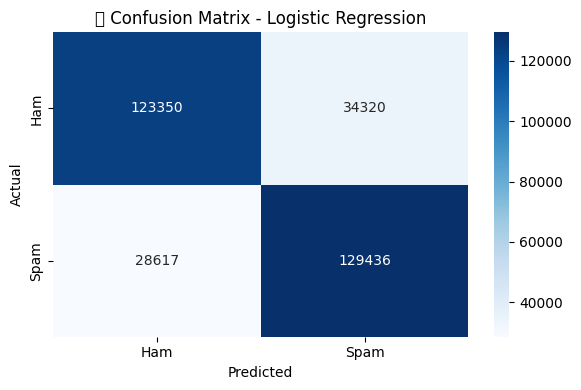

<ipython-input-16-23297d360c04>:26: UserWarning: Glyph 128217 (\N{ORANGE BOOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128217 (\N{ORANGE BOOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


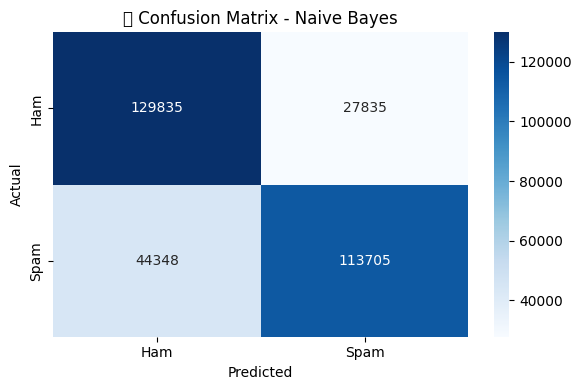

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Step 5: Visualization - Confusion Matrix for both models
# Set a common figure size for consistency
plt.figure(figsize=(6, 4))

# Confusion Matrix for Logistic Regression
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title("📘 Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Confusion Matrix for Naive Bayes
plt.figure(figsize=(6, 4))
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title("📙 Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [15]:
# New Sentiment Examples
# Step 6: Model Prediction on New SMS
new_sms = [
    "I just got a promotion at work, feeling amazing!",
    "Ugh, this day keeps getting worse.",
    "So happy to be back home with family.",
    "I'm really frustrated with how things turned out.",
    "The weather is beautiful today!",
    "Nothing ever goes my way...",
    "Enjoyed the concert so much, best night ever!",
    "I'm tired and completely out of energy.",
    "Life is good when you're surrounded by positivity.",
    "I'm done trying. Nothing works."
]

# Preprocess the new messages
new_sms_cleaned = [preprocess_text(text) for text in new_sms]

# Vectorize using TF-IDF
new_sms_tfidf = tfidf_vectorizer.transform(new_sms_cleaned)

# Predict using Logistic Regression
log_reg_predictions = log_reg_model.predict(new_sms_tfidf)

# Predict using Naive Bayes
nb_predictions = nb_model.predict(new_sms_tfidf)

# Print predictions as 0/1 with optional label
print("\n---- Sentiment Predictions on New Texts ----\n")
for i, sms in enumerate(new_sms):
    log_label = "Positive" if log_reg_predictions[i] == 1 else "Negative"
    nb_label = "Positive" if nb_predictions[i] == 1 else "Negative"

    print(f"Text {i+1}: '{sms}'")
    print(f"  Logistic Regression Prediction: {log_reg_predictions[i]} ({log_label})")
    print(f"  Naive Bayes Prediction: {nb_predictions[i]} ({nb_label})")
    print("-" * 60)



---- Sentiment Predictions on New Texts ----

Text 1: 'I just got a promotion at work, feeling amazing!'
  Logistic Regression Prediction: 0 (Negative)
  Naive Bayes Prediction: 0 (Negative)
------------------------------------------------------------
Text 2: 'Ugh, this day keeps getting worse.'
  Logistic Regression Prediction: 0 (Negative)
  Naive Bayes Prediction: 0 (Negative)
------------------------------------------------------------
Text 3: 'So happy to be back home with family.'
  Logistic Regression Prediction: 1 (Positive)
  Naive Bayes Prediction: 1 (Positive)
------------------------------------------------------------
Text 4: 'I'm really frustrated with how things turned out.'
  Logistic Regression Prediction: 1 (Positive)
  Naive Bayes Prediction: 0 (Negative)
------------------------------------------------------------
Text 5: 'The weather is beautiful today!'
  Logistic Regression Prediction: 1 (Positive)
  Naive Bayes Prediction: 1 (Positive)
-------------------------

**Declaration**

I, Nirmal Chaturvedi, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [Insert GitHub Link]

Signature: 1) Nirmal Chaturvedi
2) Vivek Borade
3) Abhijeet Jadhav